# Paper Plots:

### Author : Ricardo Queiroz (UFRN)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
from itertools import cycle
import os

font_dir = '/usr/share/fonts/truetype/msttcorefonts/'
fm.fontManager.addfont(font_dir + 'Times_New_Roman.ttf')
plt.rcParams['font.family'] = 'Times New Roman'

## Paths

In [2]:
# Changing Working Directory - Linux
campaigns_path = '/home/oai-ufrn/Repositories/open_ran_datacenter_placement/PlotResults/'
results_path = '/home/oai-ufrn/Repositories/open_ran_datacenter_placement/PlotResults'

Cp1 = 'results_Placement_Florianopolis_Magazine_Case_1_odcs/data'
Cp2 = 'results_Placement_PortoAlegre_Magazine_Case_1_odcs/data'
Cp3 = 'results_Placement_Florianopolis_Magazine_Case_2_odcs/data'
Cp4 = 'results_Placement_PortoAlegre_Magazine_Case_2_odcs/data'

## Plots

In [3]:
fontSize = 18
fontSizeLeg = 20
figsize=(14,6)
hatch=['x','+','o'] 

### Capacity

In [4]:
dfCp1_capacity = pd.read_csv(campaigns_path+Cp1+'/Capacity-System.csv',delimiter=',')
dfCp2_capacity = pd.read_csv(campaigns_path+Cp2+'/Capacity-System.csv',delimiter=',')
dfCp3_capacity = pd.read_csv(campaigns_path+Cp3+'/Capacity-System.csv',delimiter=',')
dfCp4_capacity = pd.read_csv(campaigns_path+Cp4+'/Capacity-System.csv',delimiter=',')

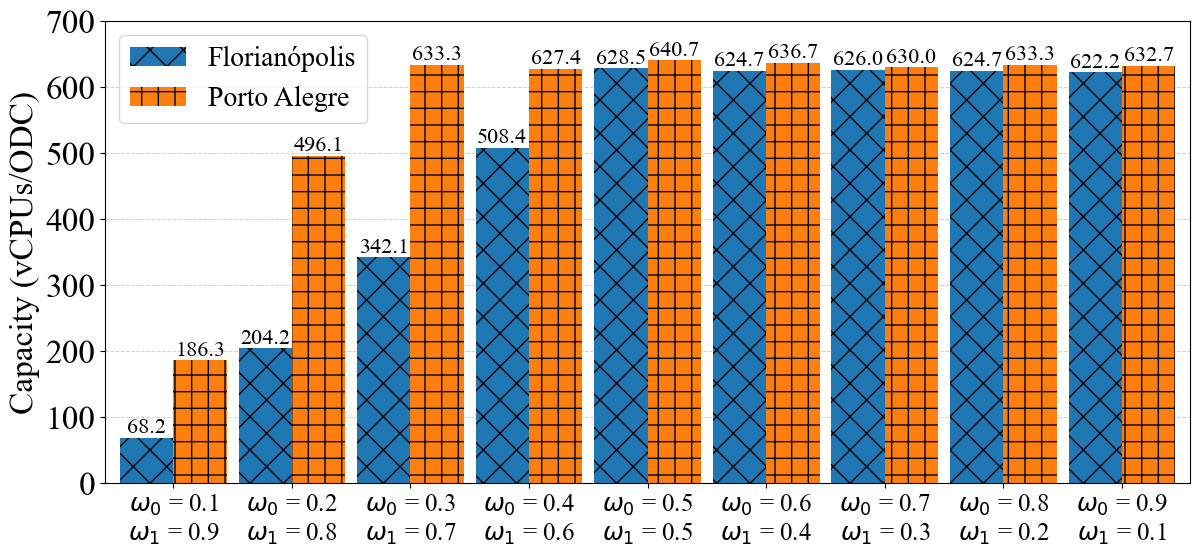

In [29]:
# DataFrames de entrada
dfs = [dfCp1_capacity, dfCp2_capacity]
labels = ["Florianópolis", "Porto Alegre"]

# Extraindo rótulos das categorias e convertendo os valores para float
categories = dfs[0].iloc[:-1, 0].str.extract(r'wodc (\d+\.\d+), wd (\d+\.\d+)')
categories = categories.apply(lambda x: f"$\omega_0$ = {x[0]}\n$\omega_1$ = {x[1]}", axis=1)

# Filtrando os valores numéricos e convertendo para float
filter = [df.iloc[:-1, 1:].astype(float) for df in dfs]

# Número de grupos e categorias
num_cols = filter[0].shape[0]
num_datasets = len(filter)
indices = np.arange(num_cols)

# Largura das barras
width = 0.45

# Criando a figura e os eixos
fig, ax = plt.subplots(figsize=figsize)
plt.rc('font', size=fontSize)

for i, df in enumerate(filter):
    values = df.iloc[:, 0]  # Pegando os valores da primeira coluna numérica de cada DataFrame
    bars = ax.bar(indices + i * width, values, width, label=labels[i], hatch=hatch[i])
    
    # Adicionando os valores acima das barras
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height, f'{height:.1f}', ha='center', va='bottom', fontsize=16)

# Configurações do gráfico
#ax.set_xlabel('Weights')
ax.set_ylabel('Capacity (vCPUs/ODC)', fontsize=fontSize+6)
ax.tick_params(axis='y', labelsize = fontSize+6)
ax.set_xticks(indices + width / 2)
ax.set_xticklabels(categories)
ax.legend(fontsize=fontSizeLeg, loc="upper left")
ax.set_yticks(np.arange(0, 701, 100))
ax.grid(True, axis='y', linestyle='--', linewidth=0.7, alpha=0.6)
ax.set_axisbelow(True)

ax.set_xlim(-0.35, num_cols-0.2)
os.makedirs(results_path, exist_ok=True)
complete_path = os.path.join(results_path, "Capacity_w1_w2.png")

plt.savefig(complete_path, dpi=600, bbox_inches='tight', transparent=True)
plt.show()


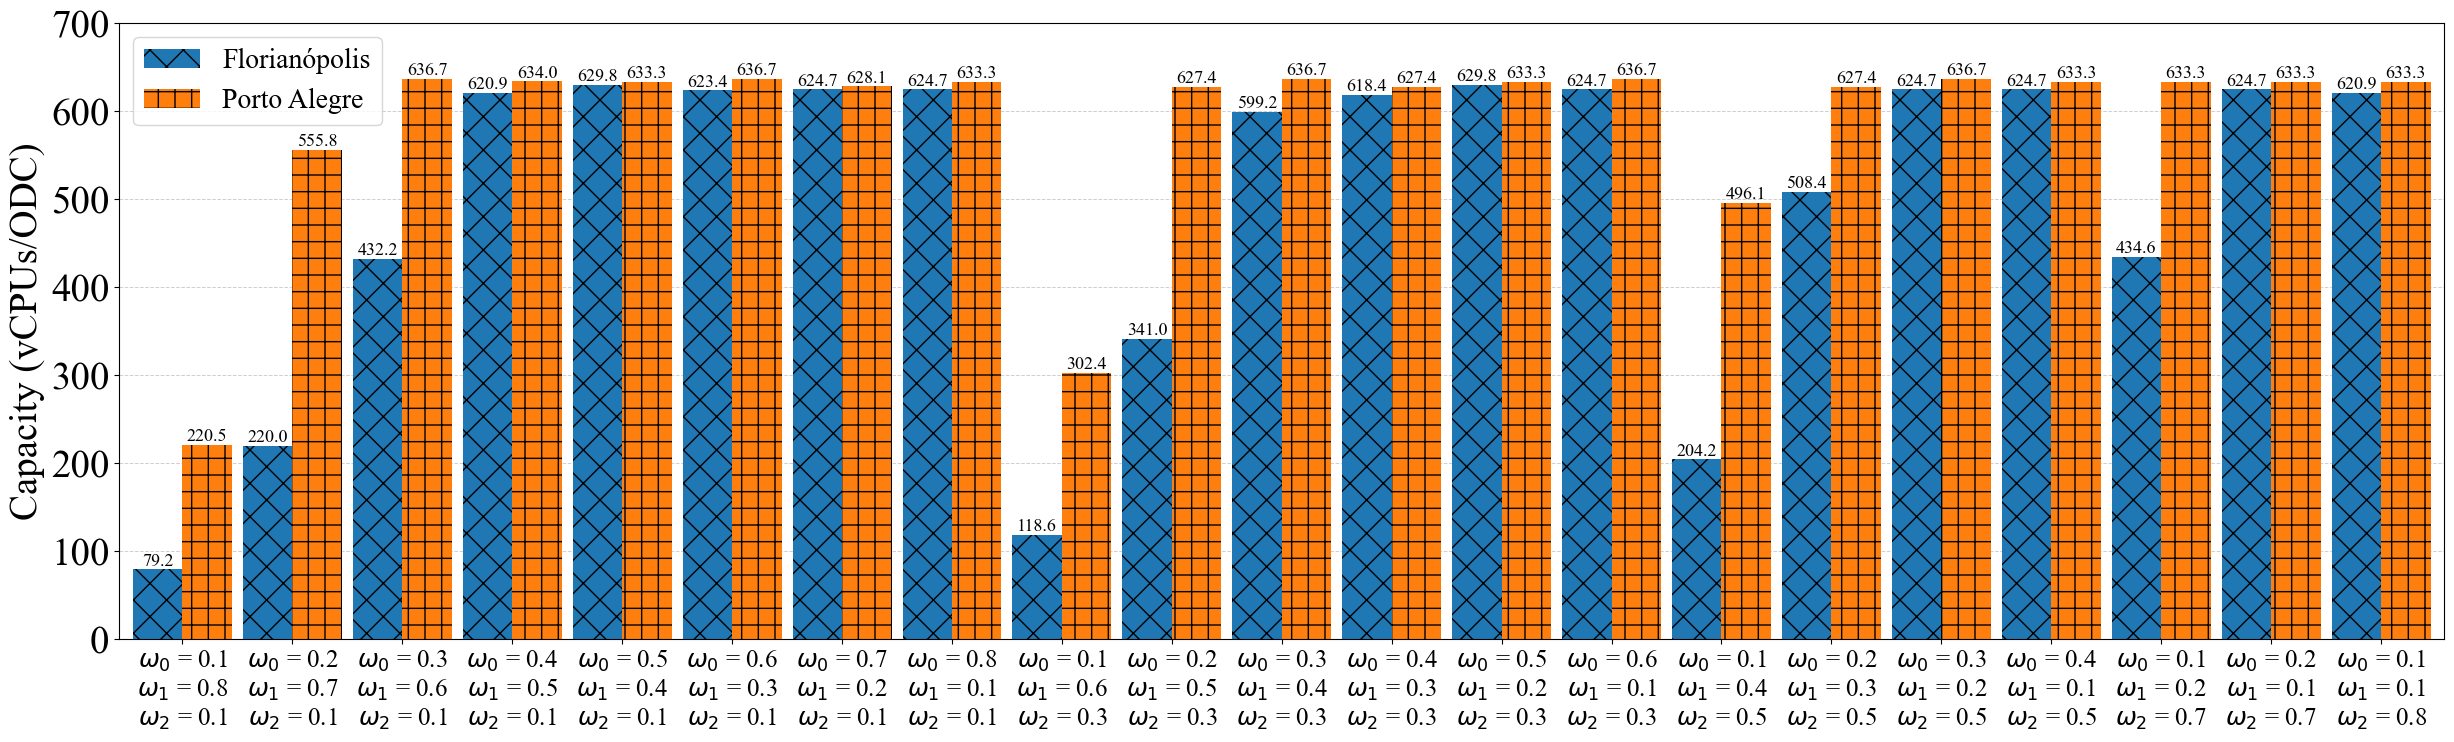

In [8]:
# DataFrames de entrada
dfs = [dfCp3_capacity, dfCp4_capacity]
labels = ["Florianópolis", "Porto Alegre"]

# Extraindo rótulos das categorias e convertendo os valores para float
categories = dfs[0].iloc[:-1, 0].str.extract(r'wcpu (\d+\.\d+), wodc (\d+\.\d+), wd (\d+\.\d+)')
categories = categories.apply(lambda x: f"$\omega_0$ = {x[1]}\n$\omega_1$ = {x[2]}\n$\omega_2$ = {x[0]}", axis=1)

# Filtrando os valores numéricos e convertendo para float
filter = [df.iloc[:-1, 1:].astype(float) for df in dfs]

# Número de grupos e categorias
num_cols = filter[0].shape[0]
num_datasets = len(filter)
indices = np.arange(num_cols)

# Largura das barras
width = 0.45

# Criando a figura e os eixos
fig, ax = plt.subplots(figsize=(30,8))
plt.rc('font', size=fontSize)

for i, df in enumerate(filter):
    values = df.iloc[:, 0]  # Pegando os valores da primeira coluna numérica de cada DataFrame
    bars = ax.bar(indices + i * width, values, width, label=labels[i], hatch=hatch[i])
    
    # Adicionando os valores acima das barras
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height, f'{height:.1f}', ha='center', va='bottom', fontsize=13)

# Configurações do gráfico
#ax.set_xlabel('Weights')
ax.set_ylabel('Capacity (vCPUs/ODC)', fontsize=fontSize+10)
ax.tick_params(axis='y', labelsize = fontSize+10)
ax.set_xticks(indices + width / 2)
ax.set_xticklabels(categories)
ax.legend(fontsize=fontSizeLeg, loc="upper left")
ax.set_yticks(np.arange(0, 701, 100))
ax.grid(True, axis='y', linestyle='--', linewidth=0.7, alpha=0.6)
ax.set_axisbelow(True)

ax.set_xlim(-0.35, num_cols-0.2)
os.makedirs(results_path, exist_ok=True)
complete_path = os.path.join(results_path, "Capacity_w0_w1_w2.png")

plt.savefig(complete_path, dpi=600, bbox_inches='tight', transparent=True)
plt.show()

### Fiber Length

In [5]:
dfCp1_fiberlength = pd.read_csv(campaigns_path+Cp1+'/Fiberlength-System.csv',delimiter=',')
dfCp2_fiberlength = pd.read_csv(campaigns_path+Cp2+'/Fiberlength-System.csv',delimiter=',')
dfCp3_fiberlength = pd.read_csv(campaigns_path+Cp3+'/Fiberlength-System.csv',delimiter=',')
dfCp4_fiberlength = pd.read_csv(campaigns_path+Cp4+'/Fiberlength-System.csv',delimiter=',')

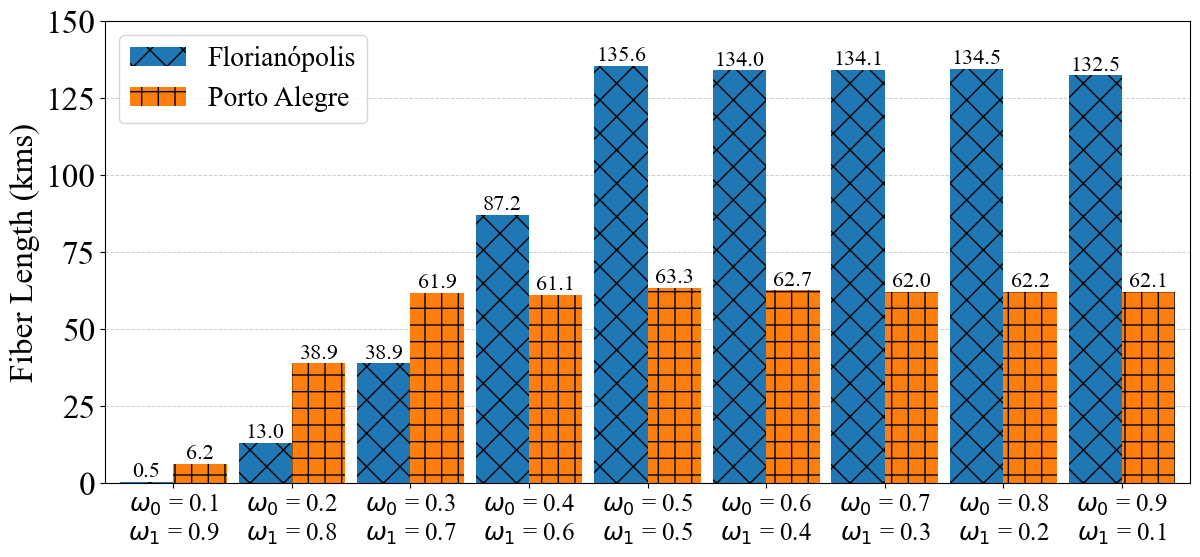

In [10]:
# DataFrames de entrada
dfs = [dfCp1_fiberlength, dfCp2_fiberlength]
labels = ["Florianópolis", "Porto Alegre"]

# Extraindo rótulos das categorias e convertendo os valores para float
categories = dfs[0].iloc[:-1, 0].str.extract(r'wodc (\d+\.\d+), wd (\d+\.\d+)')
categories = categories.apply(lambda x: f"$\omega_0$ = {x[0]}\n$\omega_1$ = {x[1]}", axis=1)

# Filtrando os valores numéricos e convertendo para float
filter = [df.iloc[:-1, 1:].astype(float) for df in dfs]

# Número de grupos e categorias
num_cols = filter[0].shape[0]
num_datasets = len(filter)
indices = np.arange(num_cols)

# Largura das barras
width = 0.45

# Criando a figura e os eixos
fig, ax = plt.subplots(figsize=figsize)
plt.rc('font', size=fontSize)

for i, df in enumerate(filter):
    values = df.iloc[:, 0]  # Pegando os valores da primeira coluna numérica de cada DataFrame
    bars = ax.bar(indices + i * width, values, width, label=labels[i], hatch=hatch[i])
    
    # Adicionando os valores acima das barras
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height, f'{height:.1f}', ha='center', va='bottom', fontsize=16)

# Configurações do gráfico
#ax.set_xlabel('Weights')
ax.set_ylabel('Fiber Length (kms)', fontsize=fontSize+6)
ax.tick_params(axis='y', labelsize = fontSize+6)
ax.set_xticks(indices + width / 2)
ax.set_xticklabels(categories)
ax.legend(fontsize=fontSizeLeg, loc="upper left")
ax.set_yticks(np.arange(0, 151, 25))
ax.grid(True, axis='y', linestyle='--', linewidth=0.7, alpha=0.6)
ax.set_axisbelow(True)

ax.set_xlim(-0.35, num_cols-0.2)
os.makedirs(results_path, exist_ok=True)
complete_path = os.path.join(results_path, "Fiberlength_w1_w2.png")

plt.savefig(complete_path, dpi=600, bbox_inches='tight', transparent=True)
plt.show()

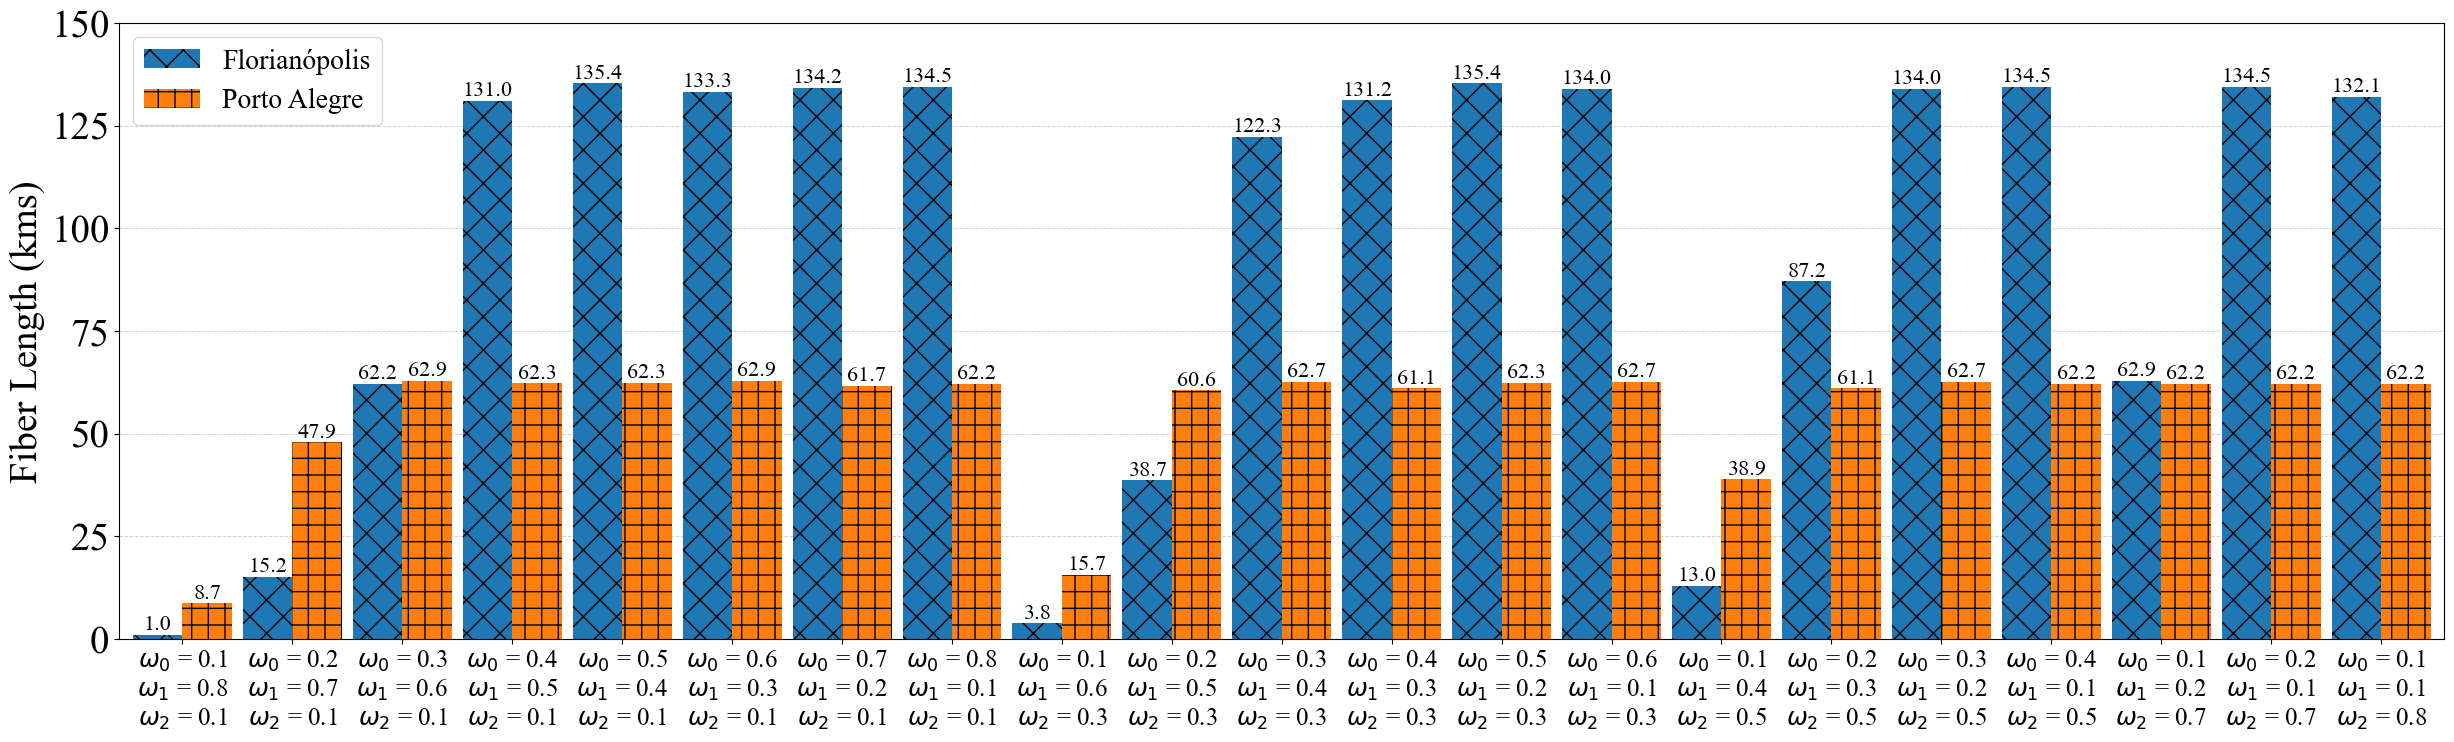

In [11]:
# DataFrames de entrada
dfs = [dfCp3_fiberlength, dfCp4_fiberlength]
labels = ["Florianópolis", "Porto Alegre"]

# Extraindo rótulos das categorias e convertendo os valores para float
categories = dfs[0].iloc[:-1, 0].str.extract(r'wcpu (\d+\.\d+), wodc (\d+\.\d+), wd (\d+\.\d+)')
categories = categories.apply(lambda x: f"$\omega_0$ = {x[1]}\n$\omega_1$ = {x[2]}\n$\omega_2$ = {x[0]}", axis=1)

# Filtrando os valores numéricos e convertendo para float
filter = [df.iloc[:-1, 1:].astype(float) for df in dfs]

# Número de grupos e categorias
num_cols = filter[0].shape[0]
num_datasets = len(filter)
indices = np.arange(num_cols)

# Largura das barras
width = 0.45

# Criando a figura e os eixos
fig, ax = plt.subplots(figsize=(30,8))
plt.rc('font', size=fontSize)

for i, df in enumerate(filter):
    values = df.iloc[:, 0]  # Pegando os valores da primeira coluna numérica de cada DataFrame
    bars = ax.bar(indices + i * width, values, width, label=labels[i], hatch=hatch[i])
    
    # Adicionando os valores acima das barras
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height, f'{height:.1f}', ha='center', va='bottom', fontsize=16)

# Configurações do gráfico
#ax.set_xlabel('Weights')
ax.set_ylabel('Fiber Length (kms)', fontsize=fontSize+10)
ax.tick_params(axis='y', labelsize = fontSize+10)
ax.set_xticks(indices + width / 2)
ax.set_xticklabels(categories)
ax.legend(fontsize=fontSizeLeg, loc="upper left")
ax.set_yticks(np.arange(0, 151, 25))
ax.grid(True, axis='y', linestyle='--', linewidth=0.7, alpha=0.6)
ax.set_axisbelow(True)

ax.set_xlim(-0.35, num_cols-0.2)
os.makedirs(results_path, exist_ok=True)
complete_path = os.path.join(results_path, "Fiberlength_w0_w1_w2.png")

plt.savefig(complete_path, dpi=600, bbox_inches='tight', transparent=True)
plt.show()

### Fiberlength vs ODC

In [7]:
dfCp1_numberODCs = pd.read_csv(campaigns_path+Cp1+'/Number_ODCs-System.csv',delimiter=',')
dfCp2_numberODCs = pd.read_csv(campaigns_path+Cp2+'/Number_ODCs-System.csv',delimiter=',')
dfCp3_numberODCs = pd.read_csv(campaigns_path+Cp3+'/Number_ODCs-System.csv',delimiter=',')
dfCp4_numberODCs = pd.read_csv(campaigns_path+Cp4+'/Number_ODCs-System.csv',delimiter=',')

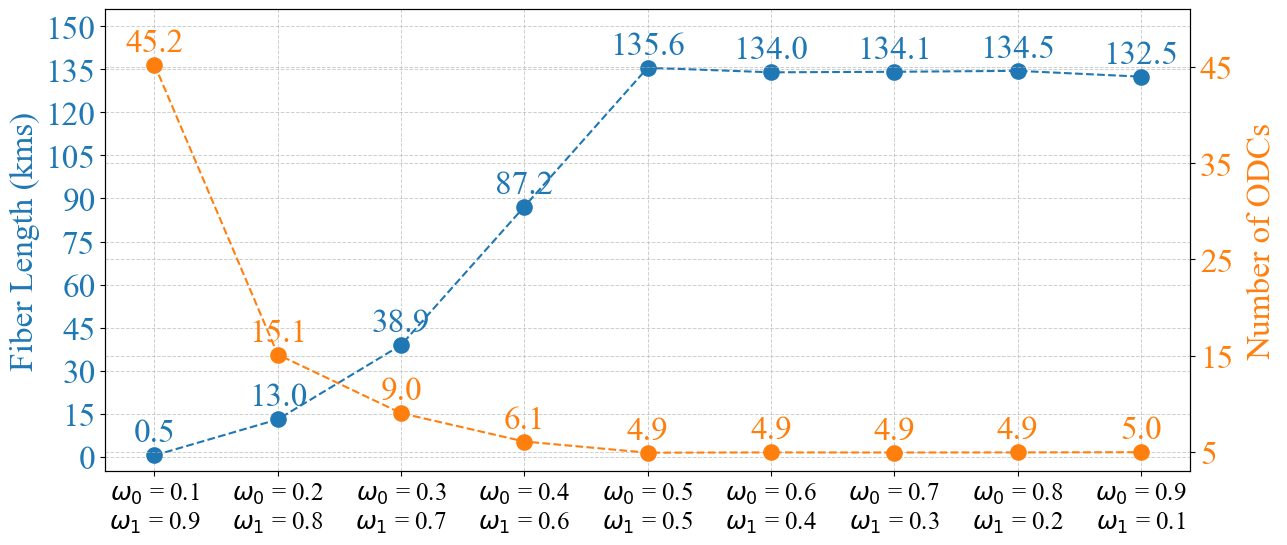

In [24]:
# DataFrames de entrada
dfs = [dfCp1_fiberlength, dfCp1_numberODCs]

# Extraindo rótulos das categorias e convertendo os valores para float
categories = dfs[0].iloc[:-1, 0].str.extract(r'wodc (\d+\.\d+), wd (\d+\.\d+)')
categories = categories.apply(lambda x: f"$\omega_0$ = {x[0]}\n$\omega_1$ = {x[1]}", axis=1)

# Filtrando os valores numéricos e convertendo para float
filtered_values = [df.iloc[:-1, 1:].astype(float) for df in dfs]

# Criando a figura e os eixos
fig, ax1 = plt.subplots(figsize=figsize)
plt.rc('font', size=fontSize)

# Definindo a paleta de cores tab10
cmap = plt.get_cmap("tab10")

# Plotando os pontos no scatter plot
x_values = np.tile(np.arange(dfs[0].shape[0] - 1), dfs[0].shape[1] - 1)  # Índices replicados
y_values = dfs[0].iloc[:-1, 1].values.flatten()  # Valores achatados
ax1.scatter(x_values, y_values, marker='o', color=cmap(0), s=120)  # Primeira cor do tab10
ax1.plot(x_values, y_values, linestyle='--', color=cmap(0))

# Configurações do gráfico
ax1.set_yticks(np.arange(0, 156, 15))
ax1.set_ylim(-5, 156)
ax1.set_ylabel("Fiber Length (kms)", color=cmap(0), fontsize=fontSize+6)
ax1.tick_params(axis='y', labelcolor=cmap(0), labelsize=fontSize+6)
ax1.set_xticks(np.arange(len(categories)))
ax1.set_xticklabels(categories)
ax1.grid(True, linestyle='--', linewidth=0.7, alpha=0.6)
ax1.set_axisbelow(True)

# Criando o segundo eixo (df2)
ax2 = ax1.twinx()
y2_values = dfs[1].iloc[:-1, 1].values.flatten()  # Valores achatados
ax2.set_yticks(np.arange(5, 76, 10))
ax2.set_ylim(3, 51)
ax2.scatter(x_values, y2_values, marker='o', color=cmap(1), s=120)  # Segunda cor do tab10
ax2.plot(x_values, y2_values, linestyle='--', color=cmap(1))
ax2.set_ylabel("Number of ODCs", color=cmap(1), fontsize=fontSize+6, labelpad=10)
ax2.tick_params(axis='y', labelcolor=cmap(1), labelsize=fontSize+6)
ax2.grid(True, linestyle='--', linewidth=0.7, alpha=0.6)
ax2.set_axisbelow(True)

# Adicionando rótulos acima dos pontos para Fiber Length
for i, (x, y) in enumerate(zip(x_values, y_values)):
    ax1.annotate(f"{y:.1f}", (x, y), textcoords="offset points", xytext=(0, 10),
                 ha='center', fontsize=fontSize+6, color=cmap(0))

# Adicionando rótulos acima dos pontos para Number of ODCs
for i, (x, y) in enumerate(zip(x_values, y2_values)):
    ax2.annotate(f"{y:.1f}", (x, y), textcoords="offset points", xytext=(0, 10),
                 ha='center', fontsize=fontSize+6, color=cmap(1))
    
# Salvando a figura
os.makedirs(results_path, exist_ok=True)
complete_path = os.path.join(results_path, "Fiberlength_vs_ODC_Florianopolis_w1_w2.png")
plt.savefig(complete_path, dpi=600, bbox_inches='tight', transparent=True)
plt.show()

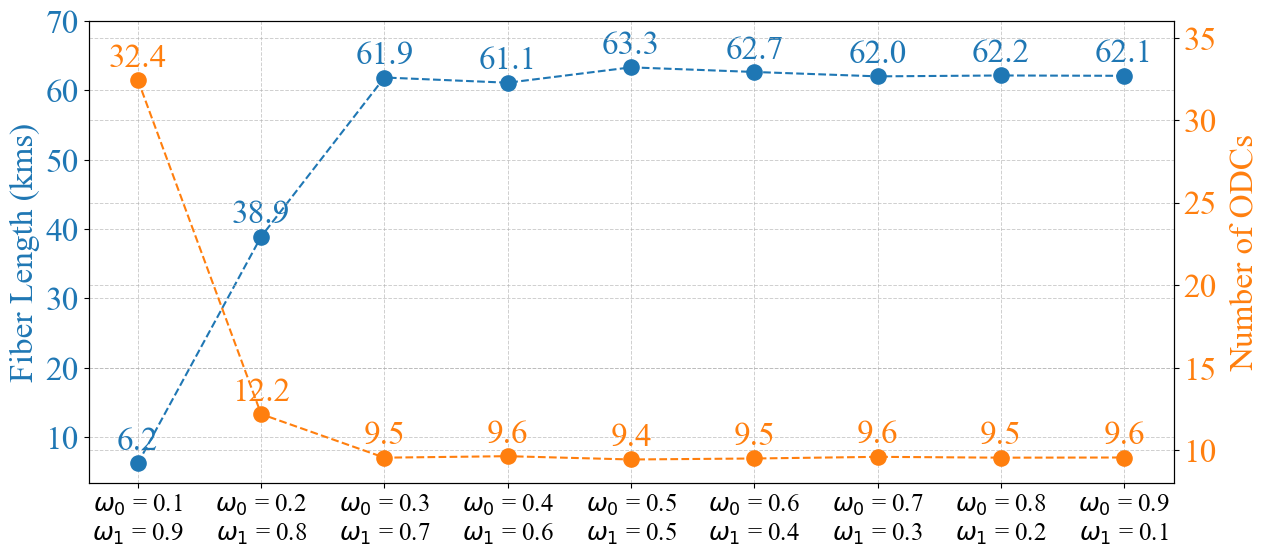

In [27]:
# DataFrames de entrada
dfs = [dfCp2_fiberlength, dfCp2_numberODCs]

# Extraindo rótulos das categorias e convertendo os valores para float
categories = dfs[0].iloc[:-1, 0].str.extract(r'wodc (\d+\.\d+), wd (\d+\.\d+)')
categories = categories.apply(lambda x: f"$\omega_0$ = {x[0]}\n$\omega_1$ = {x[1]}", axis=1)

# Filtrando os valores numéricos e convertendo para float
filtered_values = [df.iloc[:-1, 1:].astype(float) for df in dfs]

# Criando a figura e os eixos
fig, ax1 = plt.subplots(figsize=figsize)
plt.rc('font', size=fontSize)

# Definindo a paleta de cores tab10
cmap = plt.get_cmap("tab10")

# Plotando os pontos no scatter plot
x_values = np.tile(np.arange(dfs[0].shape[0] - 1), dfs[0].shape[1] - 1)  # Índices replicados
y_values = dfs[0].iloc[:-1, 1].values.flatten()  # Valores achatados
ax1.scatter(x_values, y_values, marker='o', color=cmap(0), s=120)  # Primeira cor do tab10
ax1.plot(x_values, y_values, linestyle='--', color=cmap(0))

# Configurações do gráfico
ax1.set_yticks(np.arange(10, 71, 10))
ax1.set_ylabel("Fiber Length (kms)", color=cmap(0), fontsize=fontSize+6)
ax1.tick_params(axis='y', labelcolor=cmap(0), labelsize=fontSize+6)
ax1.set_xticks(np.arange(len(categories)))
ax1.set_xticklabels(categories)
ax1.grid(True, linestyle='--', linewidth=0.7, alpha=0.6)
ax1.set_axisbelow(True)

# Criando o segundo eixo (df2)
ax2 = ax1.twinx()
y2_values = dfs[1].iloc[:-1, 1].values.flatten()  # Valores achatados
ax2.set_yticks(np.arange(5, 41, 5))
ax2.set_ylim(8, 36)
ax2.scatter(x_values, y2_values, marker='o', color=cmap(1), s=120)  # Segunda cor do tab10
ax2.plot(x_values, y2_values, linestyle='--', color=cmap(1))
ax2.set_ylabel("Number of ODCs", color=cmap(1), fontsize=fontSize+6, labelpad=10)
ax2.tick_params(axis='y', labelcolor=cmap(1), labelsize=fontSize+6)
ax2.grid(True, linestyle='--', linewidth=0.7, alpha=0.6)
ax2.set_axisbelow(True)

# Adicionando rótulos acima dos pontos para Fiber Length
for i, (x, y) in enumerate(zip(x_values, y_values)):
    ax1.annotate(f"{y:.1f}", (x, y), textcoords="offset points", xytext=(0, 10),
                 ha='center', fontsize=fontSize+6, color=cmap(0))

# Adicionando rótulos acima dos pontos para Number of ODCs
for i, (x, y) in enumerate(zip(x_values, y2_values)):
    ax2.annotate(f"{y:.1f}", (x, y), textcoords="offset points", xytext=(0, 10),
                 ha='center', fontsize=fontSize+6, color=cmap(1))

# Salvando a figura
os.makedirs(results_path, exist_ok=True)
complete_path = os.path.join(results_path, "Fiberlength_vs_ODC_PortoAlegre_w1_w2.png")
plt.savefig(complete_path, dpi=600, bbox_inches='tight', transparent=True)
plt.show()

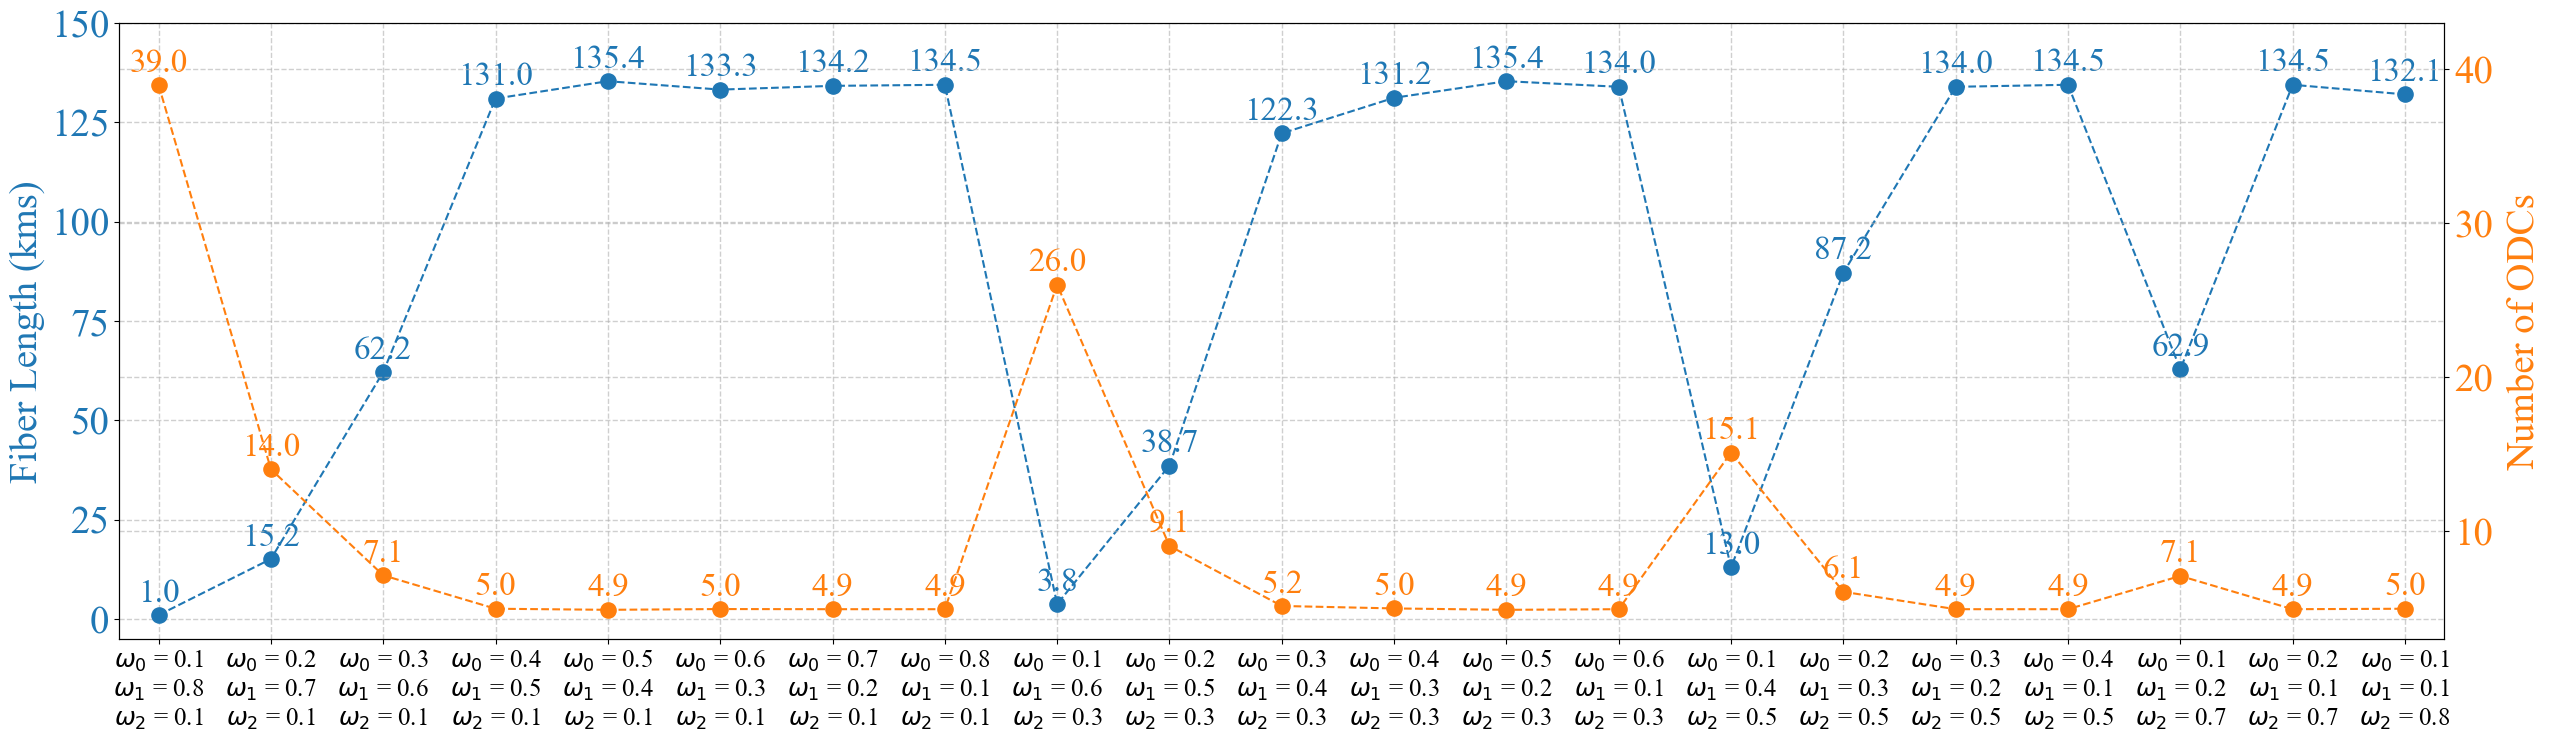

In [39]:
# DataFrames de entrada
dfs = [dfCp3_fiberlength, dfCp3_numberODCs]

# Extraindo rótulos das categorias e convertendo os valores para float
categories = dfs[0].iloc[:-1, 0].str.extract(r'wcpu (\d+\.\d+), wodc (\d+\.\d+), wd (\d+\.\d+)')
categories = categories.apply(lambda x: f"$\omega_0$ = {x[1]}\n$\omega_1$ = {x[2]}\n$\omega_2$ = {x[0]}", axis=1)

# Filtrando os valores numéricos e convertendo para float
filtered_values = [df.iloc[:-1, 1:].astype(float) for df in dfs]

# Criando a figura e os eixos
fig, ax1 = plt.subplots(figsize=(30, 8))
plt.rc('font', size=fontSize)

# Definindo a paleta de cores tab10
cmap = plt.get_cmap("tab10")

# Plotando os pontos no scatter plot
x_values = np.tile(np.arange(dfs[0].shape[0] - 1), dfs[0].shape[1] - 1)  # Índices replicados
y_values = dfs[0].iloc[:-1, 1].values.flatten()  # Valores achatados
ax1.scatter(x_values, y_values, marker='o', color=cmap(0), s=120)  # Primeira cor do tab10
ax1.plot(x_values, y_values, linestyle='--', color=cmap(0))

# Configurações do gráfico
ax1.set_ylim(-5, 150)
ax1.set_ylabel("Fiber Length (kms)", color=cmap(0), fontsize=fontSize+10)
ax1.tick_params(axis='y', labelcolor=cmap(0), labelsize=fontSize+10)
ax1.set_xticks(np.arange(len(categories)))
ax1.set_xticklabels(categories)
ax1.grid(True, linestyle='--', linewidth=1, alpha=0.6)
ax1.set_axisbelow(True)

ax1.set_xlim(-0.35, len(x_values)-0.65)

# Criando o segundo eixo (df2)
ax2 = ax1.twinx()
y2_values = dfs[1].iloc[:-1, 1].values.flatten()  # Valores achatados
ax2.set_ylim(3, 43)
ax2.scatter(x_values, y2_values, marker='o', color=cmap(1), s=120)  # Segunda cor do tab10
ax2.plot(x_values, y2_values, linestyle='--', color=cmap(1))
ax2.set_ylabel("Number of ODCs", color=cmap(1), fontsize=fontSize+10, labelpad=10)
ax2.tick_params(axis='y', labelcolor=cmap(1), labelsize=fontSize+10)
ax2.grid(True, linestyle='--', linewidth=1, alpha=0.6)
ax2.set_axisbelow(True)

# Adicionando rótulos acima dos pontos para Fiber Length
for i, (x, y) in enumerate(zip(x_values, y_values)):
    ax1.annotate(f"{y:.1f}", (x, y), textcoords="offset points", xytext=(0, 10),
                 ha='center', fontsize=fontSize+6, color=cmap(0))

# Adicionando rótulos acima dos pontos para Number of ODCs
for i, (x, y) in enumerate(zip(x_values, y2_values)):
    ax2.annotate(f"{y:.1f}", (x, y), textcoords="offset points", xytext=(0, 10),
                 ha='center', fontsize=fontSize+6, color=cmap(1))

# Salvando a figura
os.makedirs(results_path, exist_ok=True)
complete_path = os.path.join(results_path, "Fiberlength_vs_ODC_Florianopolis_w0_w1_w2.png")
plt.savefig(complete_path, dpi=600, bbox_inches='tight', transparent=True)
plt.show()

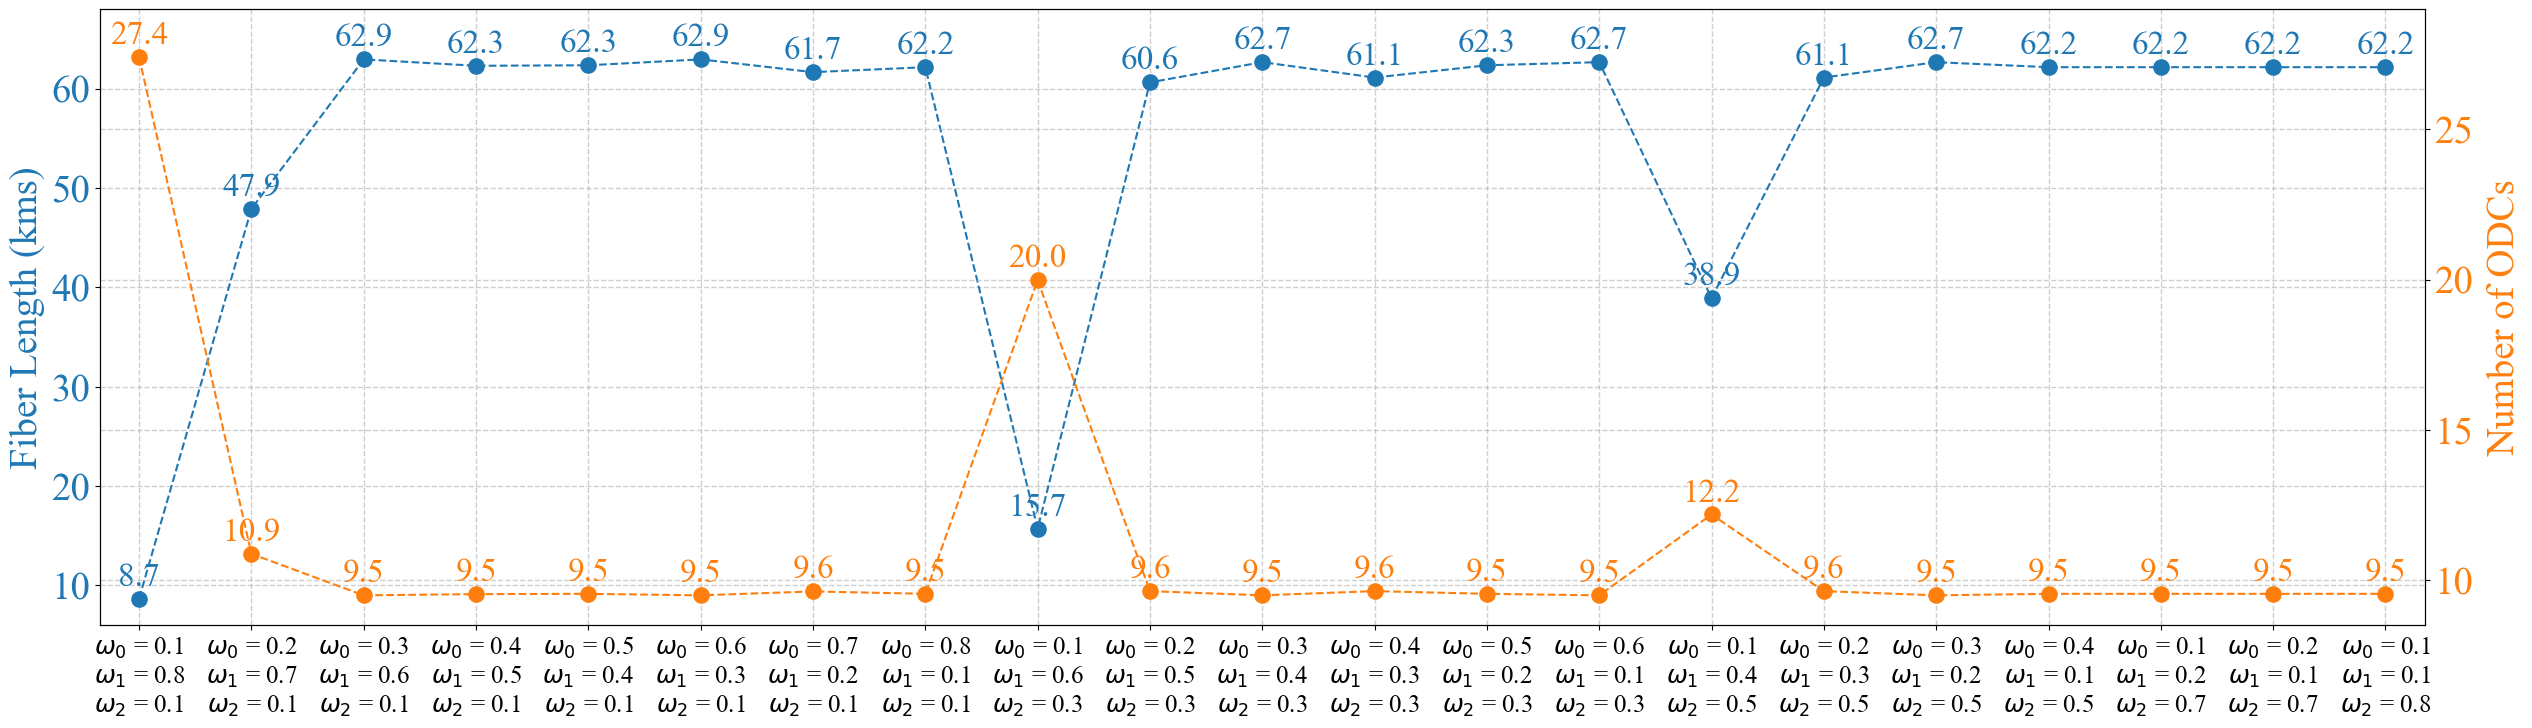

In [45]:
# DataFrames de entrada
dfs = [dfCp4_fiberlength, dfCp4_numberODCs]

# Extraindo rótulos das categorias e convertendo os valores para float
categories = dfs[0].iloc[:-1, 0].str.extract(r'wcpu (\d+\.\d+), wodc (\d+\.\d+), wd (\d+\.\d+)')
categories = categories.apply(lambda x: f"$\omega_0$ = {x[1]}\n$\omega_1$ = {x[2]}\n$\omega_2$ = {x[0]}", axis=1)

# Filtrando os valores numéricos e convertendo para float
filtered_values = [df.iloc[:-1, 1:].astype(float) for df in dfs]

# Criando a figura e os eixos
fig, ax1 = plt.subplots(figsize=(30, 8))
plt.rc('font', size=fontSize)

# Definindo a paleta de cores tab10
cmap = plt.get_cmap("tab10")

# Plotando os pontos no scatter plot
x_values = np.tile(np.arange(dfs[0].shape[0] - 1), dfs[0].shape[1] - 1)  # Índices replicados
y_values = dfs[0].iloc[:-1, 1].values.flatten()  # Valores achatados
ax1.scatter(x_values, y_values, marker='o', color=cmap(0), s=120)  # Primeira cor do tab10
ax1.plot(x_values, y_values, linestyle='--', color=cmap(0))

# Configurações do gráfico
ax1.set_ylim(6, 68)
ax1.set_ylabel("Fiber Length (kms)", color=cmap(0), fontsize=fontSize+10)
ax1.tick_params(axis='y', labelcolor=cmap(0), labelsize=fontSize+10)
ax1.set_xticks(np.arange(len(categories)))
ax1.set_xticklabels(categories)
ax1.grid(True, linestyle='--', linewidth=1, alpha=0.6)
ax1.set_axisbelow(True)

ax1.set_xlim(-0.35, len(x_values)-0.65)

# Criando o segundo eixo (df2)
ax2 = ax1.twinx()
y2_values = dfs[1].iloc[:-1, 1].values.flatten()  # Valores achatados
ax2.set_ylim(8.5, 29)
ax2.scatter(x_values, y2_values, marker='o', color=cmap(1), s=120)  # Segunda cor do tab10
ax2.plot(x_values, y2_values, linestyle='--', color=cmap(1))
ax2.set_ylabel("Number of ODCs", color=cmap(1), fontsize=fontSize+10, labelpad=10)
ax2.tick_params(axis='y', labelcolor=cmap(1), labelsize=fontSize+10)
ax2.grid(True, linestyle='--', linewidth=1, alpha=0.6)
ax2.set_axisbelow(True)

# Adicionando rótulos acima dos pontos para Fiber Length
for i, (x, y) in enumerate(zip(x_values, y_values)):
    ax1.annotate(f"{y:.1f}", (x, y), textcoords="offset points", xytext=(0, 10),
                 ha='center', fontsize=fontSize+6, color=cmap(0))

# Adicionando rótulos acima dos pontos para Number of ODCs
for i, (x, y) in enumerate(zip(x_values, y2_values)):
    ax2.annotate(f"{y:.1f}", (x, y), textcoords="offset points", xytext=(0, 10),
                 ha='center', fontsize=fontSize+6, color=cmap(1))

# Salvando a figura
os.makedirs(results_path, exist_ok=True)
complete_path = os.path.join(results_path, "Fiberlength_vs_ODC_PortoAlegre_w0_w1_w2.png")

plt.savefig(complete_path, dpi=600, bbox_inches='tight', transparent=True)
plt.show()

### Teste

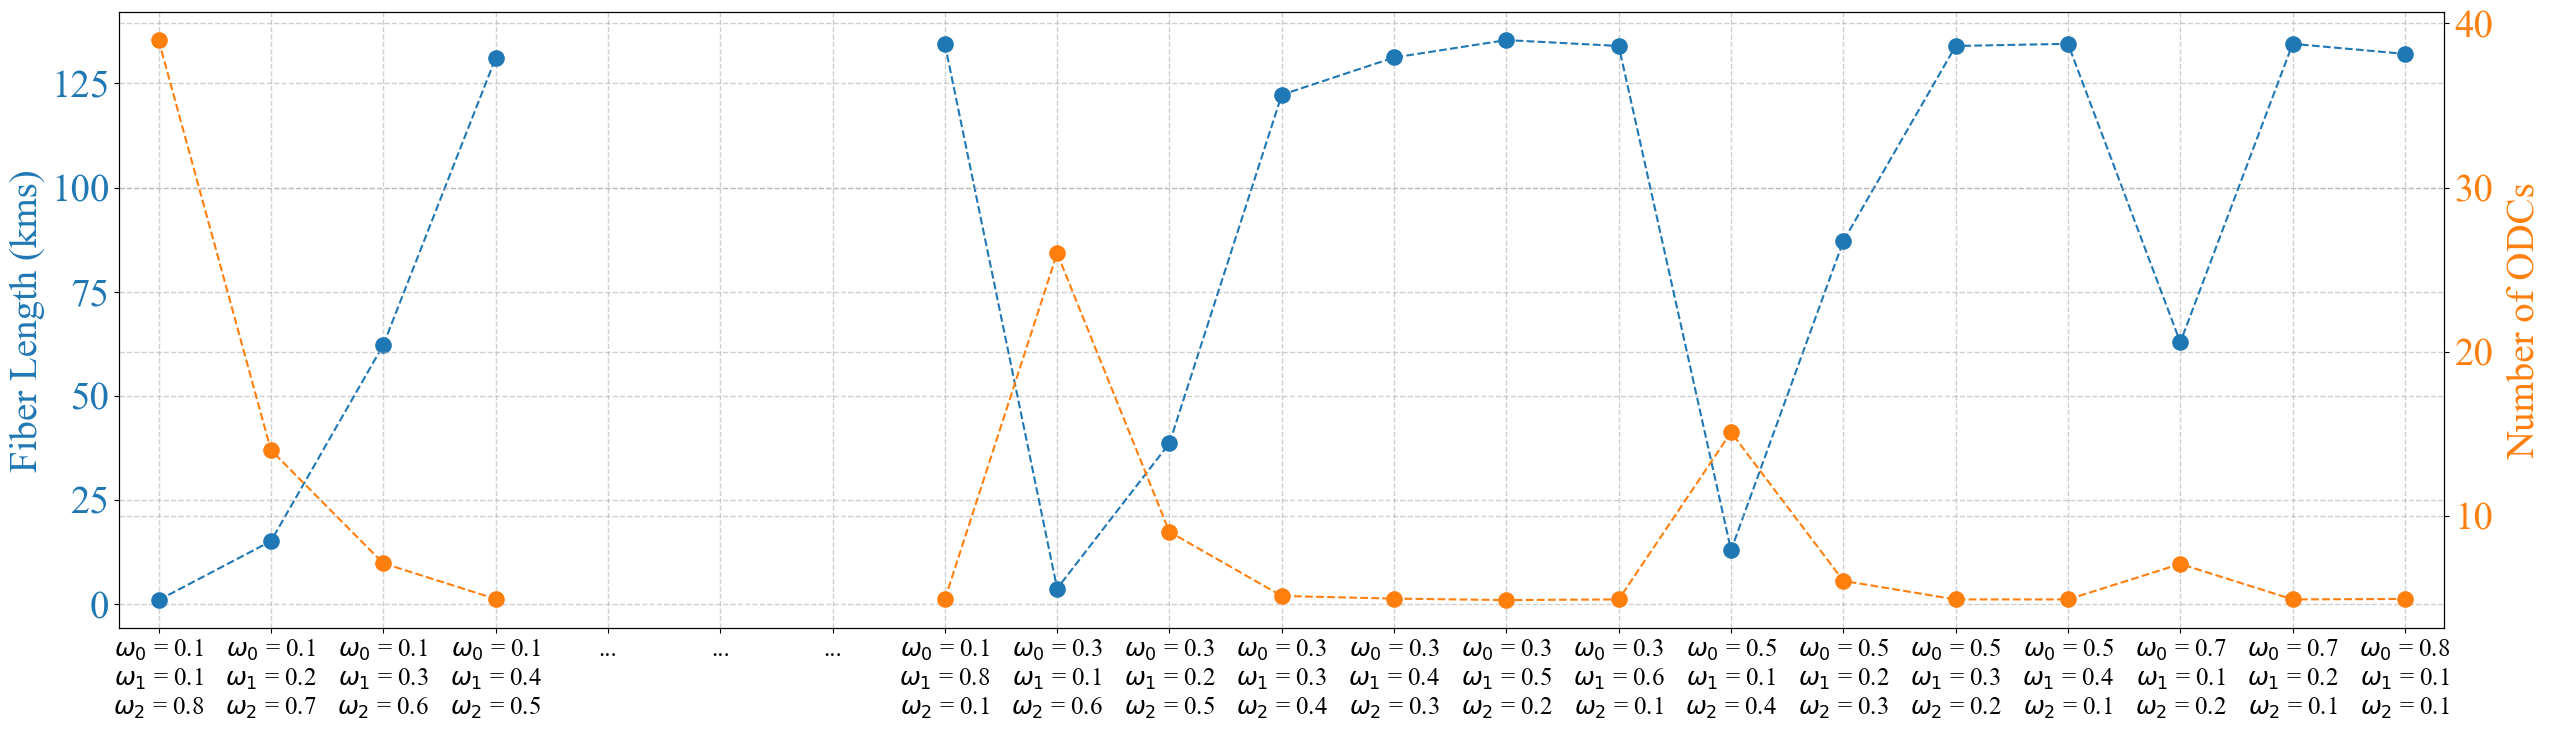

In [71]:
# Definir os índices dos pontos a serem removidos
indices_para_remover = [4, 5, 6]  # Exemplo, ajuste conforme necessário

# Criando cópias dos valores para manipulação
y_values = dfs[0].iloc[:-1, 1].values.flatten().copy()
y2_values = dfs[1].iloc[:-1, 1].values.flatten().copy()

# Substituir os valores escolhidos por np.nan
y_values[indices_para_remover] = np.nan
y2_values[indices_para_remover] = np.nan

# Criando uma cópia das categorias e substituindo os rótulos removidos por "..."
categorias_modificadas = categories.copy()
for idx in indices_para_remover:
    categorias_modificadas[idx] = "..."

# Criando a figura e os eixos
fig, ax1 = plt.subplots(figsize=(30, 8))
plt.rc('font', size=fontSize)

# Definindo a paleta de cores tab10
cmap = plt.get_cmap("tab10")

# Plotando os pontos e linhas para o primeiro eixo
x_values = np.arange(len(y_values))
ax1.scatter(x_values, y_values, marker='o', color=cmap(0), s=120)  # Primeira cor
ax1.plot(x_values, y_values, linestyle='--', color=cmap(0))

# Configurações do gráfico
ax1.set_ylabel("Fiber Length (kms)", color=cmap(0), fontsize=fontSize+10)
ax1.tick_params(axis='y', labelcolor=cmap(0), labelsize=fontSize+10)
ax1.set_xticks(np.arange(len(categories)))
ax1.set_xticklabels(categorias_modificadas)  # Aplicando os rótulos modificados
ax1.grid(True, linestyle='--', linewidth=1, alpha=0.6)
ax1.set_axisbelow(True)
ax1.set_xlim(-0.35, len(y_values) - 0.65)

# Criando o segundo eixo
ax2 = ax1.twinx()
ax2.scatter(x_values, y2_values, marker='o', color=cmap(1), s=120)  # Segunda cor
ax2.plot(x_values, y2_values, linestyle='--', color=cmap(1))
ax2.set_ylabel("Number of ODCs", color=cmap(1), fontsize=fontSize+10, labelpad=10)
ax2.tick_params(axis='y', labelcolor=cmap(1), labelsize=fontSize+10)
ax2.grid(True, linestyle='--', linewidth=1, alpha=0.6)
ax2.set_axisbelow(True)

# Salvando a figura
os.makedirs(results_path, exist_ok=True)
complete_path = os.path.join(results_path, "Fiberlength_vs_ODC_PortoAlegre_w0_w1_w2.png")

plt.savefig(complete_path, dpi=600, bbox_inches='tight', transparent=True)
plt.show()


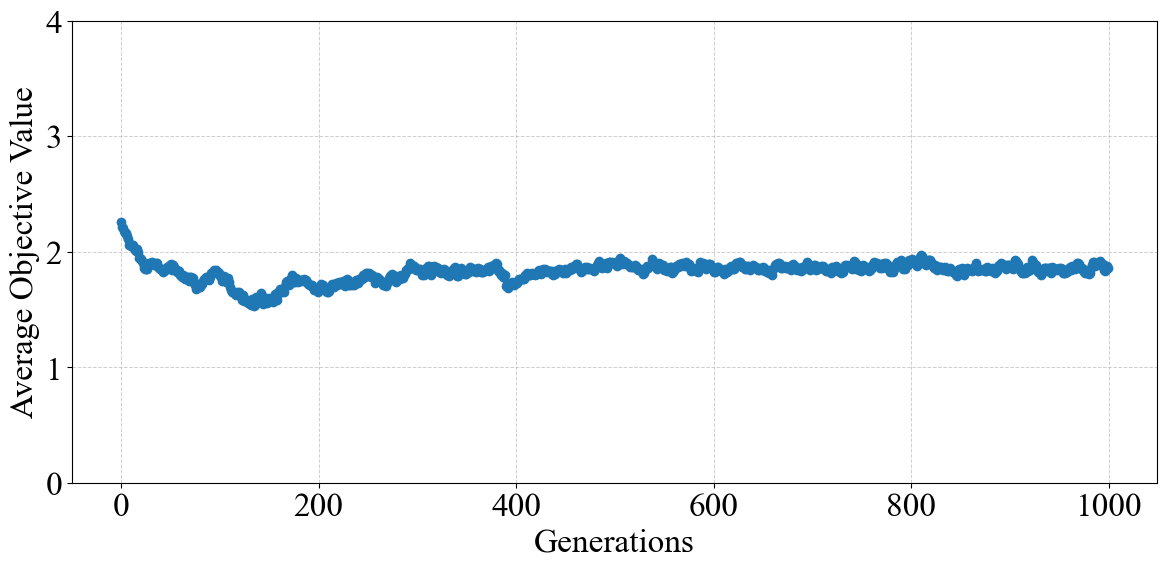

In [16]:
file_path = "/media/sf_E_DRIVE/results_Placement_PortoAlegre_Magazine_Case_1_odcs/JOB0/Sim_0/dfConvergence.csv"
df = pd.read_csv(file_path)

fig, ax = plt.subplots(figsize=figsize)
plt.rc('font', size=fontSize)

# Configurações do gráfico
#ax.set_xlabel('Weights')
ax.scatter(df['generations'], df['avg_obj'], marker='o', linestyle='-')
ax.set_xlabel("Generations", fontsize=fontSize+6)
ax.set_ylabel("Average Objective Value", fontsize=fontSize+6)
ax.tick_params(labelsize = fontSize+6)
ax.set_ylim(0, 4)
ax.grid(True, linestyle='--', linewidth=0.7, alpha=0.6)
ax.set_axisbelow(True)

os.makedirs(results_path, exist_ok=True)
complete_path = os.path.join(results_path, "ga_convergence.png")

plt.savefig(complete_path, dpi=600, bbox_inches='tight', transparent=True)
plt.show()